# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-16 09:00:00+09:00,58479.828125,58913.101562,58428.191406,58913.101562,0,0.0,0.0
2026-04-16 09:15:00+09:00,58911.019531,59072.761719,58811.691406,58820.878906,0,0.0,0.0
2026-04-16 09:30:00+09:00,58821.429688,58924.171875,58810.660156,58924.171875,0,0.0,0.0
2026-04-16 09:45:00+09:00,58927.140625,59030.691406,58911.210938,59005.660156,0,0.0,0.0
2026-04-16 10:00:00+09:00,59004.089844,59094.839844,58906.750000,59039.750000,0,0.0,0.0
2026-04-16 10:15:00+09:00,59031.730469,59154.589844,58996.359375,59047.210938,0,0.0,0.0
2026-04-16 10:30:00+09:00,59053.320312,59203.070312,59038.968750,59186.578125,0,0.0,0.0
2026-04-16 10:45:00+09:00,59180.210938,59209.980469,59138.449219,59209.339844,0,0.0,0.0
2026-04-16 11:00:00+09:00,59209.910156,59489.398438,59209.910156,59470.820312,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-04-16 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-04-16 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-04-09 00:00:00+09:00    55895.320312
2026-04-10 00:00:00+09:00    56924.109375
2026-04-13 00:00:00+09:00    56502.769531
2026-04-14 00:00:00+09:00    57877.390625
2026-04-15 00:00:00+09:00    58134.238281
2026-04-16 00:00:00+09:00    59438.921875
Name: Close, dtype: float64


Date
2026-04-15 00:00:00+09:00    58134.238281
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+345.59


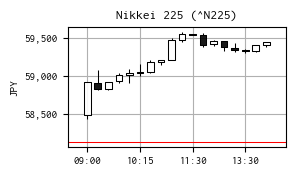

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-15 08:00:00+09:00,158.824005,158.876999,158.820999,158.875000,0,0.0,0.0
2026-04-15 08:15:00+09:00,158.867996,158.882996,158.815002,158.828003,0,0.0,0.0
2026-04-15 08:30:00+09:00,158.837006,158.839996,158.761002,158.794006,0,0.0,0.0
2026-04-15 08:45:00+09:00,158.794006,158.824997,158.772003,158.792007,0,0.0,0.0
2026-04-15 09:00:00+09:00,158.796997,158.876999,158.729996,158.871994,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-16 13:15:00+09:00,158.686996,158.727997,158.666000,158.679993,0,0.0,0.0
2026-04-16 13:30:00+09:00,158.679993,158.716003,158.649994,158.692993,0,0.0,0.0
2026-04-16 13:45:00+09:00,158.692993,158.740997,158.686005,158.707993,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-04-16 09:00:00+09:00,368.309572,371.038355,367.984361,371.038355
2026-04-16 09:15:00+09:00,371.036938,372.055632,370.411343,370.469209
2026-04-16 09:30:00+09:00,370.465699,371.112784,370.397871,371.112784
2026-04-16 09:45:00+09:00,371.243687,371.896062,371.143329,371.738364
2026-04-16 10:00:00+09:00,371.791732,372.363558,371.178382,372.016430
2026-04-16 10:15:00+09:00,371.848738,372.622646,371.625931,371.946252
2026-04-16 10:30:00+09:00,371.848884,372.791834,371.758514,372.687986
2026-04-16 10:45:00+09:00,372.800484,372.988014,372.537409,372.983978
2026-04-16 11:00:00+09:00,372.928819,374.689153,372.928819,374.572140


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-04-15 15:15:00+09:00


np.float64(158.93800354003906)

前日終値（ドル換算） 365.7667580215014


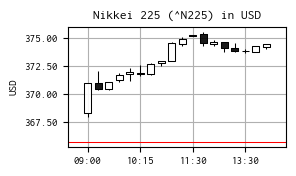

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()